In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from lmfit.models import ExponentialModel

In [2]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_03_04/afc')
OFFRES_DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
               '/Mounted_device_mk_5/10mK/2026_03_04/afc/afc_storage_offres.npz')
input_region = (0.9, 1.1)

In [11]:
data_offres = np.load(OFFRES_DATA)
time = data_offres['bins']
idx_in = np.where(np.logical_and(time > input_region[0], time < input_region[1]))[0]
counts_in = np.sum(data_offres['counts'][idx_in])

data_files = glob.glob('afc_storage_experiment*.npz', root_dir=DATA_DIR)
efficiencies = []
storage_times = []
for file in data_files:
    storage_time_str = file.split('_')[-1][:-4]  # remove '.npz'
    storage_time_unit = storage_time_str[-2:]
    storage_time = float(storage_time_str[:-2])
    if storage_time_unit == 'us':
        pass
    elif storage_time_unit == 'ns':
        # if storage_time == 200:
        #     print('skipping 200 ns')
        #     continue
        storage_time *= 1e-3
    else:
        raise ValueError(f'Unrecognized storage time unit "{storage_time_unit}"')
    storage_times.append(storage_time)

    data = np.load(os.path.join(DATA_DIR, file))
    echo_start = input_region[0] + storage_time
    echo_end = input_region[1] + storage_time
    idx_echo = np.where(np.logical_and(time > echo_start, time < echo_end))[0]
    counts_echo = np.sum(data['counts'][idx_echo])
    efficiency = counts_echo / counts_in
    efficiencies.append(efficiency)
    print(f'efficiency: {efficiency*100:.2f}%')

efficiency: 6.45%
efficiency: 8.04%
efficiency: 1.49%
efficiency: 5.10%
efficiency: 0.18%
efficiency: 6.66%


In [13]:
storage_times, efficiencies = zip(*sorted(zip(storage_times, efficiencies)))

## Fittinng (excluding 200 ns)

In [14]:
ignore_idx = 1

# fitting
model = ExponentialModel()
res = model.fit(efficiencies[ignore_idx:], x=storage_times[ignore_idx:])

print(res.fit_report())

[[Model]]
    Model(exponential)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 5
    # variables        = 2
    chi-square         = 2.4608e-05
    reduced chi-square = 8.2028e-06
    Akaike info crit   = -57.1092900
    Bayesian info crit = -57.8904142
    R-squared          = 0.99441521
[[Variables]]
    amplitude:  0.09502509 +/- 0.00374836 (3.94%) (init = 1)
    decay:      2.87796061 +/- 0.24983573 (8.68%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, decay) = -0.7793


In [21]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (4, 3)  # inches
dpi = 300
include_subplot_titles = False

# colors
color_source = '#7570b3'
color_memory = '#d95f02'

# figure layout
vertical_ratios = (1, 1)  # for two plots
horizontal_ratios = (4, 2)
vertical_padding = 0.02
horizontal_padding = 0.02

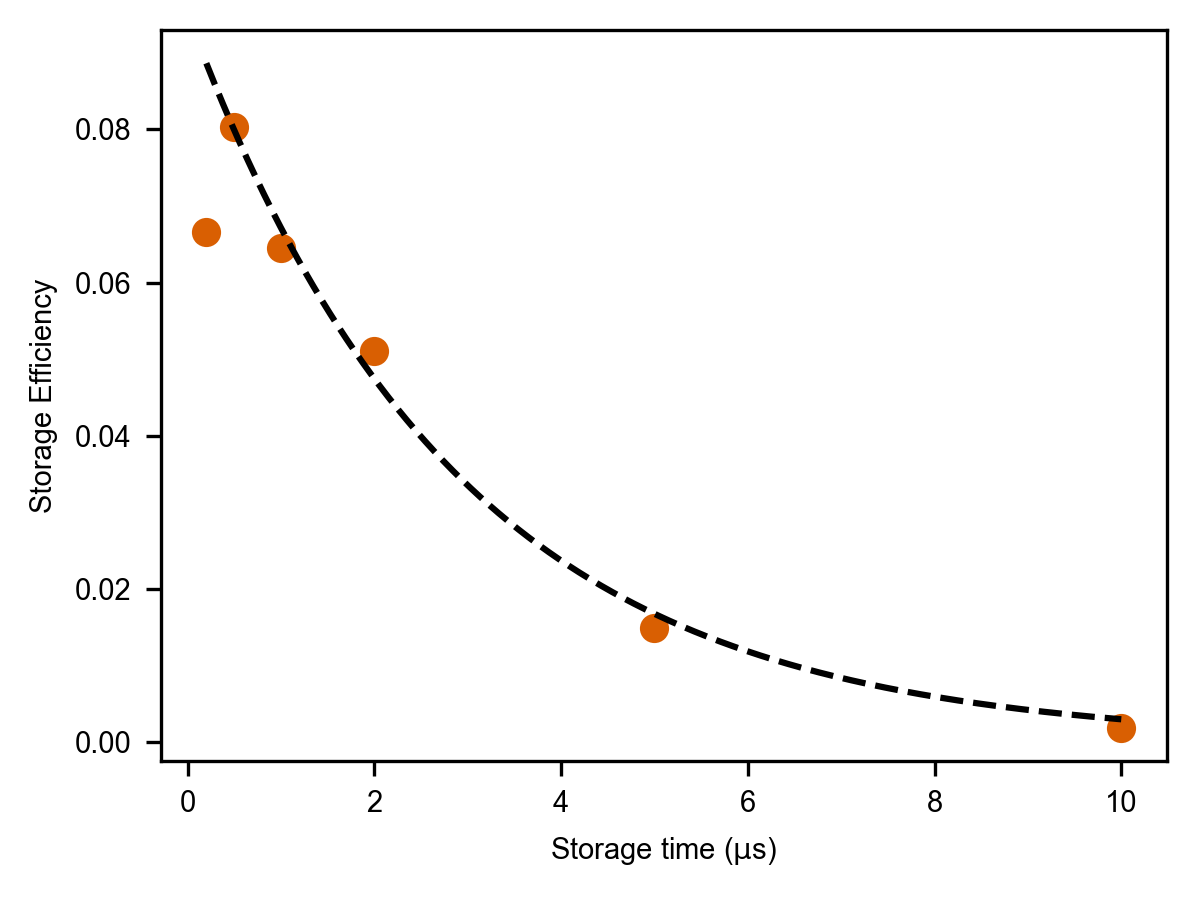

In [22]:
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

x_points_for_fit = np.linspace(min(storage_times), max(storage_times), 1000)
plt.plot(storage_times, efficiencies,
         ls='', marker='o', color=color_memory)
plt.plot(x_points_for_fit, res.eval(x=x_points_for_fit),
         ls='--', color='k')
plt.xlabel(r'Storage time ($\mathrm{\mu}$s)')
plt.ylabel('Storage Efficiency')
plt.tight_layout()

In [23]:
fig.savefig('sup_storage_time.pdf')